# 02 · Learn what is worth inspecting

Created by Shivam Bharadwaj · [Benchmark home](../README.md) · [Protocol](../PROTOCOL.md)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/projects/goallab/build-goallab/notebooks/02_baselines_and_dqn.ipynb)

**Question:** can a small Q-network investigate more effectively than a readable rule?

You will compare a metadata-first baseline with DQN, examine its actual stopping choices, and distinguish a training curve from held-out success. A learned policy is like an apprentice reviewer: it may learn a useful shortcut, or copy a correlation that disappears in a new workspace.

**Prerequisites:** course notebooks 03–04 and benchmark lab 01. **Outcome:** a trained controller and a budgeted comparison.

![The investigation loop and independent final evaluation](../architecture.svg)

**Run:** restart the kernel and run all cells. Each lab is independent. The default uses CPU, no API key, and no pretrained-model download. Colab runs need the published repository revision. Code is MIT; educational text and plots are CC BY 4.0.

In [1]:
import sys, subprocess, tempfile, json
from pathlib import Path
IN_COLAB = 'google.colab' in sys.modules
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p/'rl_course/goallab_benchmark.py').exists()), None)
if ROOT is None and IN_COLAB:
    ROOT = Path('/content/Reinforcement-Learning-Course')
    if not ROOT.exists():
        subprocess.run(['git','clone','--depth','1','https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git',str(ROOT)],check=True)
    subprocess.run([sys.executable,'-m','pip','install','-q','numpy','matplotlib','torch'],check=True)
if ROOT is None or not (ROOT/'rl_course/goallab_benchmark.py').exists():
    raise FileNotFoundError('Use the full repository revision containing GoalLab-v2.')
sys.path.insert(0,str(ROOT))
import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import display, Markdown
from rl_course import goallab_benchmark as g, goallab_training as train
torch.set_num_threads(2)
ARTIFACTS = Path(tempfile.mkdtemp(prefix='goallab-lab-'))
plt.rcParams.update({'figure.figsize':(9,4),'figure.facecolor':'#f5f1e8','axes.facecolor':'#f5f1e8',
    'axes.spines.top':False,'axes.spines.right':False,'axes.prop_cycle':plt.cycler(color=['#af824a','#657951','#87708c','#292332'])})
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+'|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(str(v) for v in row)+' |' for row in rows)))
print(g.VERSION, '| Torch',torch.__version__, '| device: CPU | artifacts:',ARTIFACTS)

GoalLab-v2 | Torch 2.11.0+cu130 | device: CPU | artifacts: /tmp/goallab-lab-h5p3fx43


## 1. Establish the rule baseline

The rule checks metadata in recency order, reads eligible evidence, resolves dependencies, and stops. It never sees the answer key. Run it first: learning needs to justify its extra cost against a meaningful baseline.

In [2]:
case=g.make_case(4,'GoalLab-Test',5)
run=train.investigate(case,'Greedy',8)
table(['Action','Cost','Remaining'],[[e['action'],e['cost'],e['observation']['remaining']] for e in run.events])
print('Final evaluation:',g.verify(case,run.artifact,run.observation()))

| Action | Cost | Remaining |
|---|---|---|
| inspect metadata 6 | 1 | 7 |
| inspect metadata 3 | 1 | 6 |
| open source 6 | 1 | 5 |
| STOP: answer 2, confidence 95% | 1 | 4 |

Final evaluation: {'success': True, 'accuracy': True, 'supported': True, 'evidence_precision': 1.0, 'evidence_recall': 1.0, 'unsupported': False, 'brier': 0.0025000000000000044}


## 2. Inspect the update you are training

Double DQN chooses the next action with the online network and evaluates it with the target network. Terminal transitions receive no bootstrap value. The action mask removes unaffordable or redundant actions, but it does not force the agent to obtain sufficient evidence before stopping. Premature answers remain a possible failure.

With reward −0.03, discount 0.99, and next value 0.8, a nonterminal target is 0.762. If that transition ends the episode, its target is only −0.03.

In [3]:
reward,discount,next_value=-.03,.99,.8
print('Nonterminal target:',reward+discount*next_value)
print('Terminal target:',reward)
import inspect
print(inspect.getsource(train.train_dqn))

Nonterminal target: 0.762
Terminal target: -0.03
def train_dqn(seed=7, episodes=1200):
    torch.manual_seed(seed)
    rng = random.Random(seed)
    model = Controller()
    target = deepcopy(model).requires_grad_(False)
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
    replay = deque(maxlen=12000)
    steps, history = 0, []
    for episode in range(episodes):
        env = training_case(rng)
        total = 0.
        while not env.done:
            obs = env.observation()
            valid = np.flatnonzero(g.mask(obs))
            epsilon = max(.08, 1-episode/max(1, episodes*.8))
            a = int(rng.choice(valid)) if rng.random() < epsilon else policy_action(model, obs)
            ns = env.step(a)
            reward = shaped_reward(env, a, obs)
            replay.append((g.features(obs), a, reward, g.features(ns), env.done, g.mask(ns)))
            steps += 1
            total += reward
            if len(replay) >= 64:
                batch = rng.sample(list(rep

## 3. Train a compact controller

The default below is a quick 600-episode run. Use 2400 episodes and seeds 7, 19, 31 for the reference protocol. Training cases come only from GoalLab-Train. Potential-based shaping supplies an observed-evidence progress signal and vanishes at terminal states; it does not replace the independent completion metric.

Parameters: 12832
Training tool actions: 2509


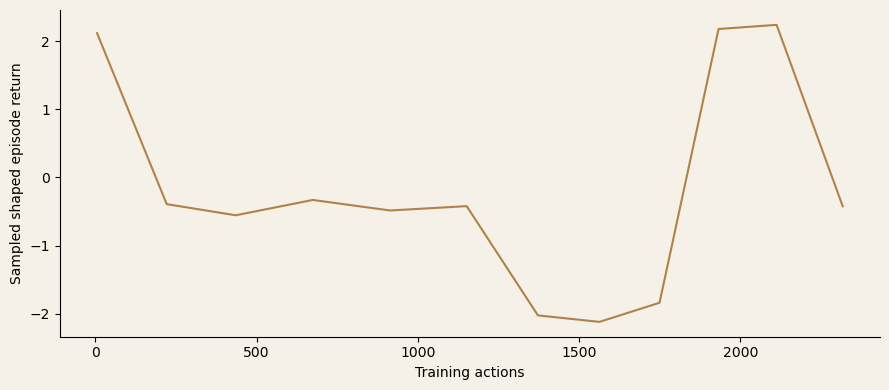

In [4]:
EPISODES=600
model,training=train.train_dqn(seed=7,episodes=EPISODES)
print('Parameters:',sum(p.numel() for p in model.parameters()))
print('Training tool actions:',training['actions'])
h=training['history']
plt.plot([r['actions'] for r in h],[r['return'] for r in h]);plt.xlabel('Training actions');plt.ylabel('Sampled shaped episode return');plt.tight_layout();plt.show()

## 4. Freeze weights and evaluate

Use the same case IDs for both methods. Include exhaustion and abstention in the denominator. The challenge set changes a cue the baseline uses, while retaining the underlying rule for valid support. A high score here is specific to this structured schema.

In [5]:
records=[]
for split in g.SPLITS[1:]:
    for budget in [4,8,12]:
        for i in range(30):
            case=g.make_case(i,split,i%5+1)
            for method in ['Greedy','DQN']:
                records.append(train.record(train.investigate(case,method,budget,model),method,7))
summary=train.aggregate(records)
table(['Set','Budget','Method','Verified','Mean cost'],[[r['split'],r['budget'],r['method'],f"{r['success']:.1%}",round(r['average_cost'],2)] for r in summary])

| Set | Budget | Method | Verified | Mean cost |
|---|---|---|---|---|
| GoalLab-Challenge | 4 | DQN | 0.0% | 3.87 |
| GoalLab-Challenge | 4 | Greedy | 0.0% | 4.0 |
| GoalLab-Challenge | 8 | DQN | 66.7% | 7.57 |
| GoalLab-Challenge | 8 | Greedy | 100.0% | 7.93 |
| GoalLab-Challenge | 12 | DQN | 100.0% | 7.87 |
| GoalLab-Challenge | 12 | Greedy | 100.0% | 7.93 |
| GoalLab-Test | 4 | DQN | 0.0% | 3.77 |
| GoalLab-Test | 4 | Greedy | 73.3% | 3.53 |
| GoalLab-Test | 8 | DQN | 83.3% | 7.67 |
| GoalLab-Test | 8 | Greedy | 100.0% | 4.27 |
| GoalLab-Test | 12 | DQN | 100.0% | 8.17 |
| GoalLab-Test | 12 | Greedy | 100.0% | 4.27 |

## 5. Change a constraint and inspect a failure

Predict the effect of a four-unit budget. Find the first unsuccessful DQN investigation in the deterministic evaluation order; do not select a failure just because it supports your preferred explanation. Distinguish no answer, wrong answer, and unsupported answer.

In [6]:
failure=next((r for r in records if r['method']=='DQN' and not r['evaluation']['success']),None)
if failure:
    print(failure['case'],failure['budget'],failure['evaluation'])
    table(['Action','Cost'],[[e['action'],e['cost']] for e in failure['events']])
else:
    print('No failure in this finite sample; reduce the budget or expand the case set.')
torch.save(model.state_dict(),ARTIFACTS/'dqn.pt')

GoalLab-Test/1/0 4 {'success': False, 'accuracy': False, 'supported': False, 'evidence_precision': 0.0, 'evidence_recall': 0.0, 'unsupported': False, 'brier': None}


| Action | Cost |
|---|---|
| open source 4 | 1 |
| inspect metadata 1 | 1 |
| inspect metadata 6 | 1 |
| inspect metadata 5 | 1 |

## Interpret the result

The network sees structured source features, not document language. It chooses tools and stopping actions; deterministic tools extract values and assemble support. Compare the rule and learned controller at the same allowance, and report the training interactions separately. One seed is a learning exercise, not a stable algorithm ranking.

**Next:** [PPO and learned verification](03_ppo_and_verifier.ipynb).